# Section 1: Data Verification

| # | Figure | Description |
|---|--------|-------------|
| 1 | Trial inventory | Original vs preprocessed trial counts, missing blocks, split distribution |
| 2 | Trial count summary | Bar chart of DBS-OFF / DBS-ON trial counts per session |
| 3-6 | PSD DBS comparison | Power spectral density per ECoG channel, 4 sessions |
| 7 | Tracing speed DBS comparison | Mean velocity & acceleration traces by DBS condition |
| 8 | PSID nx/n1 selection | Validation-set curves for total dim (nx) and behavioral subspace (n1) selection |
| 9 | DPAD training curves | Train/val RMSE across 4 internal stages, per session and experiment |

In [1]:
import sys, os

os.chdir("/home/bobby/repos/latent-neural-dynamics-modeling")
sys.path.insert(0, ".")
sys.path.insert(0, "notebooks")

In [2]:
import json
from collections import namedtuple
from pathlib import Path
import numpy as np
import polars as pl
import yaml
import matplotlib.pyplot as plt
from scipy.signal import welch
from scipy.stats import mannwhitneyu, false_discovery_control
import matplotlib.cm as cm

from modules.style import (
    COLOR_DBS_OFF,
    COLOR_DBS_ON,
    COLOR_DPAD,
    COLOR_PSID,
    apply_thesis_style,
    hex_to_rgba,
    panel_label,
    stack_bar_label,
)
from modules.loaders import (
    discover_session_run,
    get_latest_variant_dir,
    EXP_Z_AS_BEHAVIOR,
    EXP_Z_AS_NEURAL,
    SESSIONS,
)

apply_thesis_style()

In [3]:
OUT = Path("thesis_figures/sec1")
OUT.mkdir(parents=True, exist_ok=True)
results_root = Path("results").resolve()
# PSD cells read the raw pre-split parquets — current per-session PSID variants
# only keep a selected subset of neural bands, so the split parquets no longer
# contain all 4 ECoG channels or the Laplacian contacts used by the PSD cells.
raw_data_root = Path(
    "resampled_recordings/participants_at_200Hz_scaled_1e6_narrow_band"
)
ECOG_CHANNELS = ["ECOG_1", "ECOG_2", "ECOG_3", "ECOG_4"]

In [4]:
# Session registry — auto-discovered via discover_session_run.
SessionSpec = namedtuple(
    "SessionSpec", ["label", "participant", "session", "psid_variant", "psid_run_ts"]
)

session_specs = []
for name in SESSIONS:
    var, ts = discover_session_run(results_root, "psid", EXP_Z_AS_BEHAVIOR, name)
    if not var:
        continue
    pid, sess = name.split("_S")
    session_specs.append(
        SessionSpec(
            label=name,
            participant=pid,
            session=int(sess),
            psid_variant=var,
            psid_run_ts=ts,
        )
    )

In [5]:
FS_SPLIT = 200
MARGIN_S = 2
MARGIN_SAMP = MARGIN_S * FS_SPLIT
ECOG_CHANNEL_IDS = [1, 2, 3, 4]
LAP_CHANNEL_NAMES = ["9-11", "10-12", "11-13", "12-14", "13-15", "14-16"]
raw_data_root = Path(
    "resampled_recordings/participants_at_200Hz_scaled_1e6_narrow_band"
)


def _session_raw_files(participant, session):
    return sorted(
        (raw_data_root / f"participant_id={participant}" / f"session={session}").glob(
            "*/*.parquet"
        )
    )

## DBS significance heatmap (sessions × frequency)

Band power is pooled across channels first (mean over the 4 ECoG channels / the 6
Laplacian channels built from LFP 9–16), then a single Mann-Whitney U test
is run per session × band on the pooled per-trial values. Colour encodes the signed
rank-biserial correlation $r = 2U/(n_{on} n_{off}) - 1$ on a diverging scale
($-1$ … $+1$); positive $r$ means larger band power under DBS-ON. Significance is a
single $\alpha = 0.05$ applied to Benjamini-Hochberg FDR-corrected $p$-values across
the bands within each session row — cells that fail the
correction ($q \ge 0.05$) are crossed out.

Computing pooled ECoG band statistics...


Computing pooled Laplacian LFP band statistics...


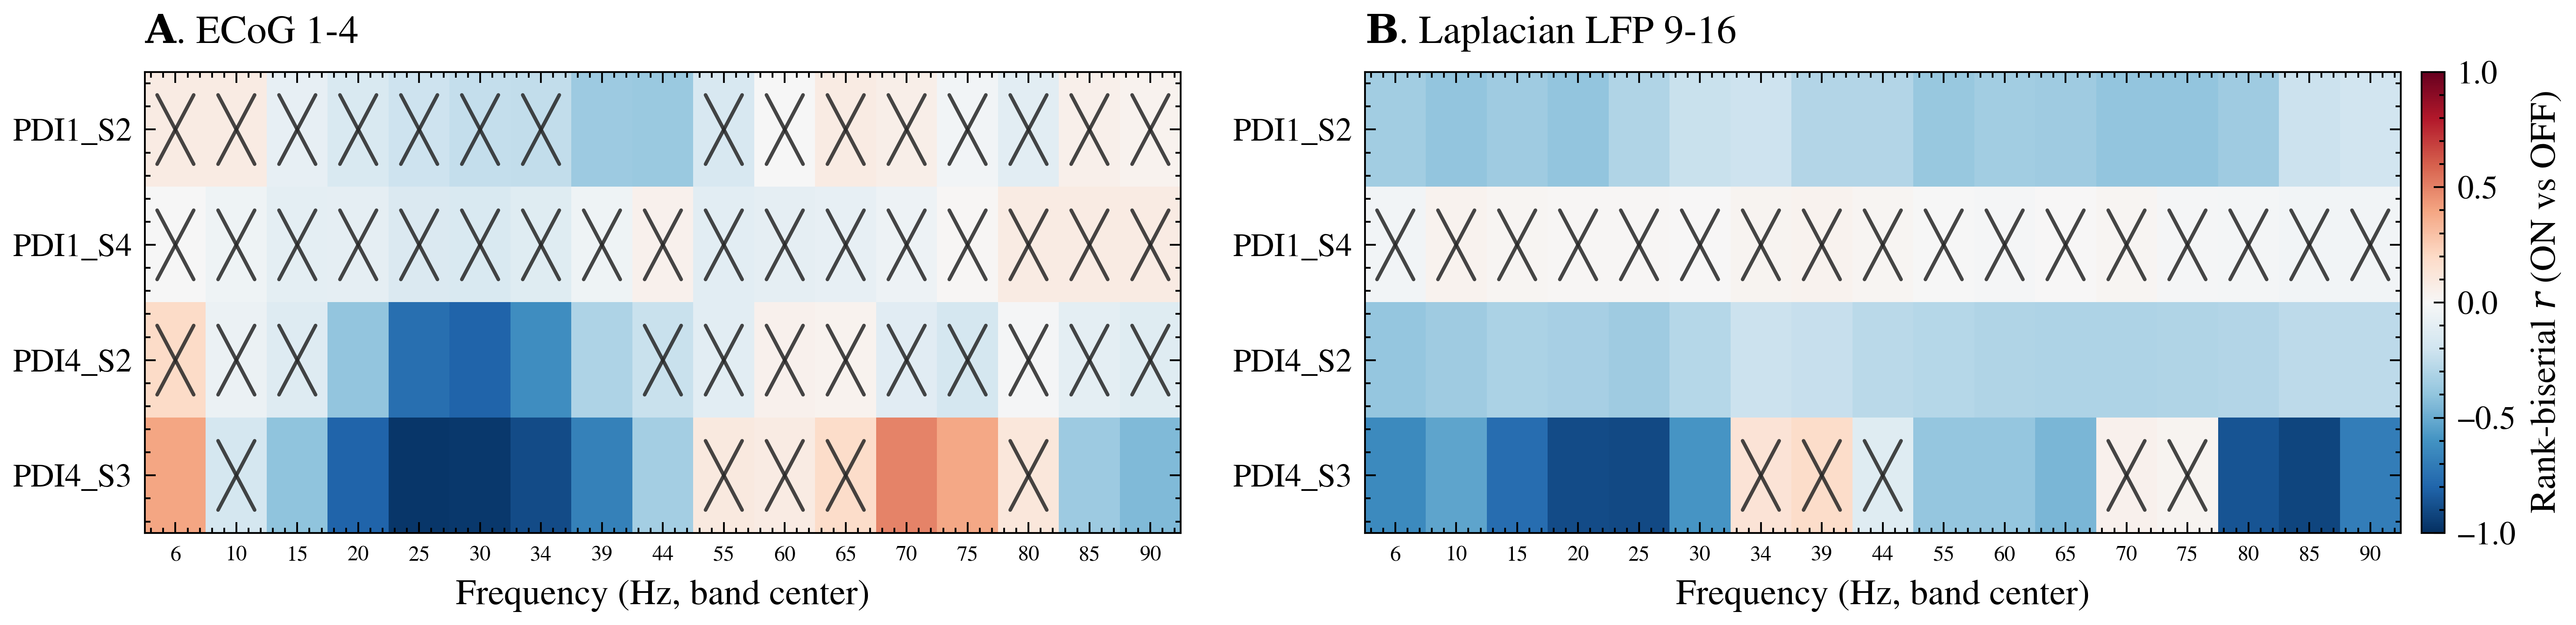

Saved -> fig_006_dbs_significance_heatmap.png

Trials entering the pooled DBS test (all usable trials, pre-split):
  session      OFF    ON  total
  PDI1_S2       72    72    144
  PDI1_S4       58    58    116
  PDI4_S2       60    59    119
  PDI4_S3       48    72    120

Pooled Mann-Whitney U per session x band — ECoG:
session  band  n_on  n_off    U    p_raw     q_bh      r
PDI1_S2   4-8    72     72 2805 3.96e-01 5.93e-01 +0.082
PDI1_S2  8-12    72     72 2799 4.09e-01 5.93e-01 +0.080
PDI1_S2 13-18    72     72 2383 4.05e-01 5.93e-01 -0.081
PDI1_S2 18-23    72     72 2201 1.19e-01 2.88e-01 -0.151
PDI1_S2 23-28    72     72 2059 3.34e-02 1.13e-01 -0.206
PDI1_S2 28-32    72     72 1970 1.30e-02 5.53e-02 -0.240
PDI1_S2 32-37    72     72 1948 1.01e-02 5.53e-02 -0.248
PDI1_S2 37-42    72     72 1657 1.89e-04 1.60e-03 -0.361
PDI1_S2 42-47    72     72 1621 1.05e-04 1.60e-03 -0.375
PDI1_S2 53-58    72     72 2167 8.99e-02 2.55e-01 -0.164
PDI1_S2 58-63    72     72 2586 9.82e-01 9.82e-0

In [6]:
import pandas as pd
from statsmodels.stats.multitest import multipletests

# DBS separability heatmap — band power is pooled across channels FIRST (mean over
# the 4 ECoG channels / the 6 Laplacian channels of LFP 9-16), then ONE Mann-Whitney U per
# session x band on the pooled per-trial values. Colour is the signed rank-biserial
# correlation r = 2U/(n_on*n_off) - 1, oriented ON vs OFF (r > 0 -> larger power
# under DBS-ON). Significance is a single alpha = 0.05 on BH-FDR-corrected p-values
# across bands within each session row; cells failing the correction (q >= 0.05) are
# crossed out rather than faded, so the effect size stays readable in every cell.

ALPHA_SIG = 0.05


def _cross_nonsig(ax, qm, finite, color="0.15", lw=1.0, alpha=0.85, inset=0.30):
    """Draw an X over every cell that fails BH-FDR at ALPHA_SIG.

    Cells with a finite effect size but q >= ALPHA_SIG (or no testable q) are
    crossed; missing cells are left blank. The strokes are inset from the cell
    edge so that neighbouring crossed cells stay visually separate instead of
    fusing into a continuous lattice, and the line style is pinned so the axes
    property cycle cannot alternate it. Axis limits are restored afterwards so
    the strokes cannot rescale the image.
    """
    nonsig = finite & ~(np.isfinite(qm) & (qm < ALPHA_SIG))
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    for i, j in zip(*np.nonzero(nonsig)):
        ax.plot([j - inset, j + inset], [i - inset, i + inset], color=color,
                lw=lw, alpha=alpha, linestyle="-", solid_capstyle="round",
                zorder=3)
        ax.plot([j - inset, j + inset], [i + inset, i - inset], color=color,
                lw=lw, alpha=alpha, linestyle="-", solid_capstyle="round",
                zorder=3)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

# The band decomposition used for modelling and reported in the methods: 17 bands
# spanning 4-93 Hz with a 47-53 Hz gap around mains. These live in the raw_envelope
# recordings, not in the narrow_band set the PSD cells read (which stops at 80 Hz and
# carries a different set of band edges), so this cell resolves its own data root.
band_data_root = Path(
    "resampled_recordings/participants_at_200Hz_scaled_1e6_raw_envelope"
)


def _session_band_files(participant, session):
    return sorted(
        (band_data_root / f"participant_id={participant}" / f"session={session}").glob(
            "*/*.parquet"
        )
    )


BAND_ORDER = [
    ("theta_4_8", 4, 8),
    ("alpha_8_12", 8, 12),
    ("beta_13_18", 13, 18),
    ("beta_18_23", 18, 23),
    ("beta_23_28", 23, 28),
    ("beta_28_32", 28, 32),
    ("gamma_32_37", 32, 37),
    ("gamma_37_42", 37, 42),
    ("gamma_42_47", 42, 47),
    ("gamma_53_58", 53, 58),
    ("gamma_58_63", 58, 63),
    ("gamma_63_68", 63, 68),
    ("gamma_68_73", 68, 73),
    ("gamma_73_78", 73, 78),
    ("gamma_78_83", 78, 83),
    ("gamma_83_88", 83, 88),
    ("gamma_88_93", 88, 93),
]

ECOG_PREFIXES = [f"ECOG_{ch}_" for ch in ECOG_CHANNEL_IDS]
LAP_PREFIXES = [f"LAPLACIAN_{name}_LFP_" for name in LAP_CHANNEL_NAMES]


def _pooled_band_stats(channel_prefixes, modality):
    """Pool band power over channels, then one Mann-Whitney U per session x band.

    Returns ``(rmat, qmat, records, counts)``: ``rmat``/``qmat`` are
    (sessions x bands) arrays of signed rank-biserial r and BH-FDR q; ``records``
    is a flat per-cell traceability list; ``counts`` maps session label ->
    (n_off, n_on) trials entering the test.
    """
    n_bands = len(BAND_ORDER)
    rmat = np.full((len(session_specs), n_bands), np.nan)
    qmat = np.full((len(session_specs), n_bands), np.nan)
    records, counts = [], {}
    cols_needed = ["stim"] + [
        f"{pref}{bn}_raw" for pref in channel_prefixes for bn, _, _ in BAND_ORDER
    ]
    for si, s in enumerate(session_specs):
        off_powers, on_powers = [], []
        for fp in _session_band_files(s.participant, s.session):
            df = pl.read_parquet(fp, columns=cols_needed)
            for row in df.iter_rows(named=True):
                cond = "off" if row["stim"] in ("off", "0") else "on"
                powers = []
                for bn, _, _ in BAND_ORDER:
                    # Pool across channels first: mean band power over channels.
                    per_chan = []
                    for pref in channel_prefixes:
                        arr = np.array(row[f"{pref}{bn}_raw"], dtype=float)
                        arr = arr[MARGIN_SAMP:-MARGIN_SAMP]
                        per_chan.append(np.nanmean(arr**2))
                    powers.append(np.nanmean(per_chan))
                (off_powers if cond == "off" else on_powers).append(powers)
        counts[s.label] = (len(off_powers), len(on_powers))
        if len(off_powers) < 2 or len(on_powers) < 2:
            continue
        off_a, on_a = np.array(off_powers), np.array(on_powers)
        n_off, n_on = len(off_a), len(on_a)
        u_stat = np.full(n_bands, np.nan)
        raw_p = np.full(n_bands, np.nan)
        r_bis = np.full(n_bands, np.nan)
        for bi in range(n_bands):
            try:
                u_stat[bi], raw_p[bi] = mannwhitneyu(
                    on_a[:, bi], off_a[:, bi], alternative="two-sided"
                )
            except ValueError:
                continue
            r_bis[bi] = 2.0 * u_stat[bi] / (n_on * n_off) - 1.0
        # Benjamini-Hochberg FDR across bands, within this session row.
        adj = np.full(n_bands, np.nan)
        valid = np.isfinite(raw_p)
        if valid.any():
            adj[valid] = multipletests(
                raw_p[valid], alpha=ALPHA_SIG, method="fdr_bh"
            )[1]
        rmat[si] = r_bis
        qmat[si] = adj
        for bi, (_, lo, hi) in enumerate(BAND_ORDER):
            records.append(
                {
                    "session": s.label,
                    "modality": modality,
                    "band": f"{lo}-{hi}",
                    "n_on": n_on,
                    "n_off": n_off,
                    "U": u_stat[bi],
                    "p_raw": raw_p[bi],
                    "q_bh": adj[bi],
                    "r": r_bis[bi],
                }
            )
    return rmat, qmat, records, counts


print("Computing pooled ECoG band statistics...")
rmat_ecog, qmat_ecog, rec_ecog, counts_ecog = _pooled_band_stats(
    ECOG_PREFIXES, "ECoG"
)

print("Computing pooled Laplacian LFP band statistics...")
rmat_lap, qmat_lap, rec_lap, counts_lap = _pooled_band_stats(LAP_PREFIXES, "LFP")

sess_labels = [s.label for s in session_specs]
band_centers = [f"{int((lo + hi) / 2)}" for _, lo, hi in BAND_ORDER]
# Shared -log10(q) ceiling, kept for the behavioral heatmap in the next cell.
global_vmax = float(
    np.nanmax(
        [
            np.nanmax(-np.log10(np.maximum(qmat_ecog, 1e-20))),
            np.nanmax(-np.log10(np.maximum(qmat_lap, 1e-20))),
        ]
    )
)

fig, (ax_ecog, ax_lap) = plt.subplots(1, 2, figsize=(10.0, 2.5), layout="constrained")

for ax, rm, qm, letter, title in [
    (ax_ecog, rmat_ecog, qmat_ecog, "A", "ECoG 1-4"),
    (ax_lap, rmat_lap, qmat_lap, "B", "Laplacian LFP 9-16"),
]:
    finite = np.isfinite(rm)
    r_disp = np.where(finite, rm, 0.0)
    # Every measured cell is drawn at full opacity; significance is marked by
    # crossing out the cells that fail BH-FDR (q >= 0.05).
    ax.imshow(
        r_disp,
        aspect="auto",
        cmap="RdBu_r",
        vmin=-1.0,
        vmax=1.0,
        alpha=np.where(finite, 1.0, 0.0),
        interpolation="nearest",
    )
    _cross_nonsig(ax, qm, finite)
    ax.set_xticks(range(len(BAND_ORDER)))
    ax.set_xticklabels(band_centers, fontsize=6)
    ax.set_yticks(range(len(sess_labels)))
    ax.set_yticklabels(sess_labels)
    ax.set_xlabel("Frequency (Hz, band center)")
    panel_label(ax, letter, title)

sm = cm.ScalarMappable(cmap="RdBu_r", norm=plt.Normalize(vmin=-1.0, vmax=1.0))
fig.colorbar(
    sm,
    ax=ax_lap,
    label="Rank-biserial $r$ (ON vs OFF)",
    fraction=0.05,
    pad=0.02,
)
fig.savefig(str(OUT / "fig_006_dbs_significance_heatmap.png"))
plt.show()
print("Saved -> fig_006_dbs_significance_heatmap.png")

# --- Trial counts actually entering the pooled test (all usable trials, pre-split) ---
print("\nTrials entering the pooled DBS test (all usable trials, pre-split):")
print(f"  {'session':10s} {'OFF':>5s} {'ON':>5s} {'total':>6s}")
for lab in sess_labels:
    n_off, n_on = counts_ecog[lab]
    print(f"  {lab:10s} {n_off:5d} {n_on:5d} {n_off + n_on:6d}")
if counts_lap != counts_ecog:
    print("  WARNING: ECoG and LFP trial counts differ ->", counts_lap)

# --- Traceability: per session x band x modality statistics ---
for modality, recs in [("ECoG", rec_ecog), ("Laplacian LFP", rec_lap)]:
    tbl = pd.DataFrame(recs)[
        ["session", "band", "n_on", "n_off", "U", "p_raw", "q_bh", "r"]
    ]
    print(f"\nPooled Mann-Whitney U per session x band — {modality}:")
    print(
        tbl.to_string(
            index=False,
            formatters={
                "U": "{:.0f}".format,
                "p_raw": "{:.2e}".format,
                "q_bh": "{:.2e}".format,
                "r": "{:+.3f}".format,
            },
        )
    )

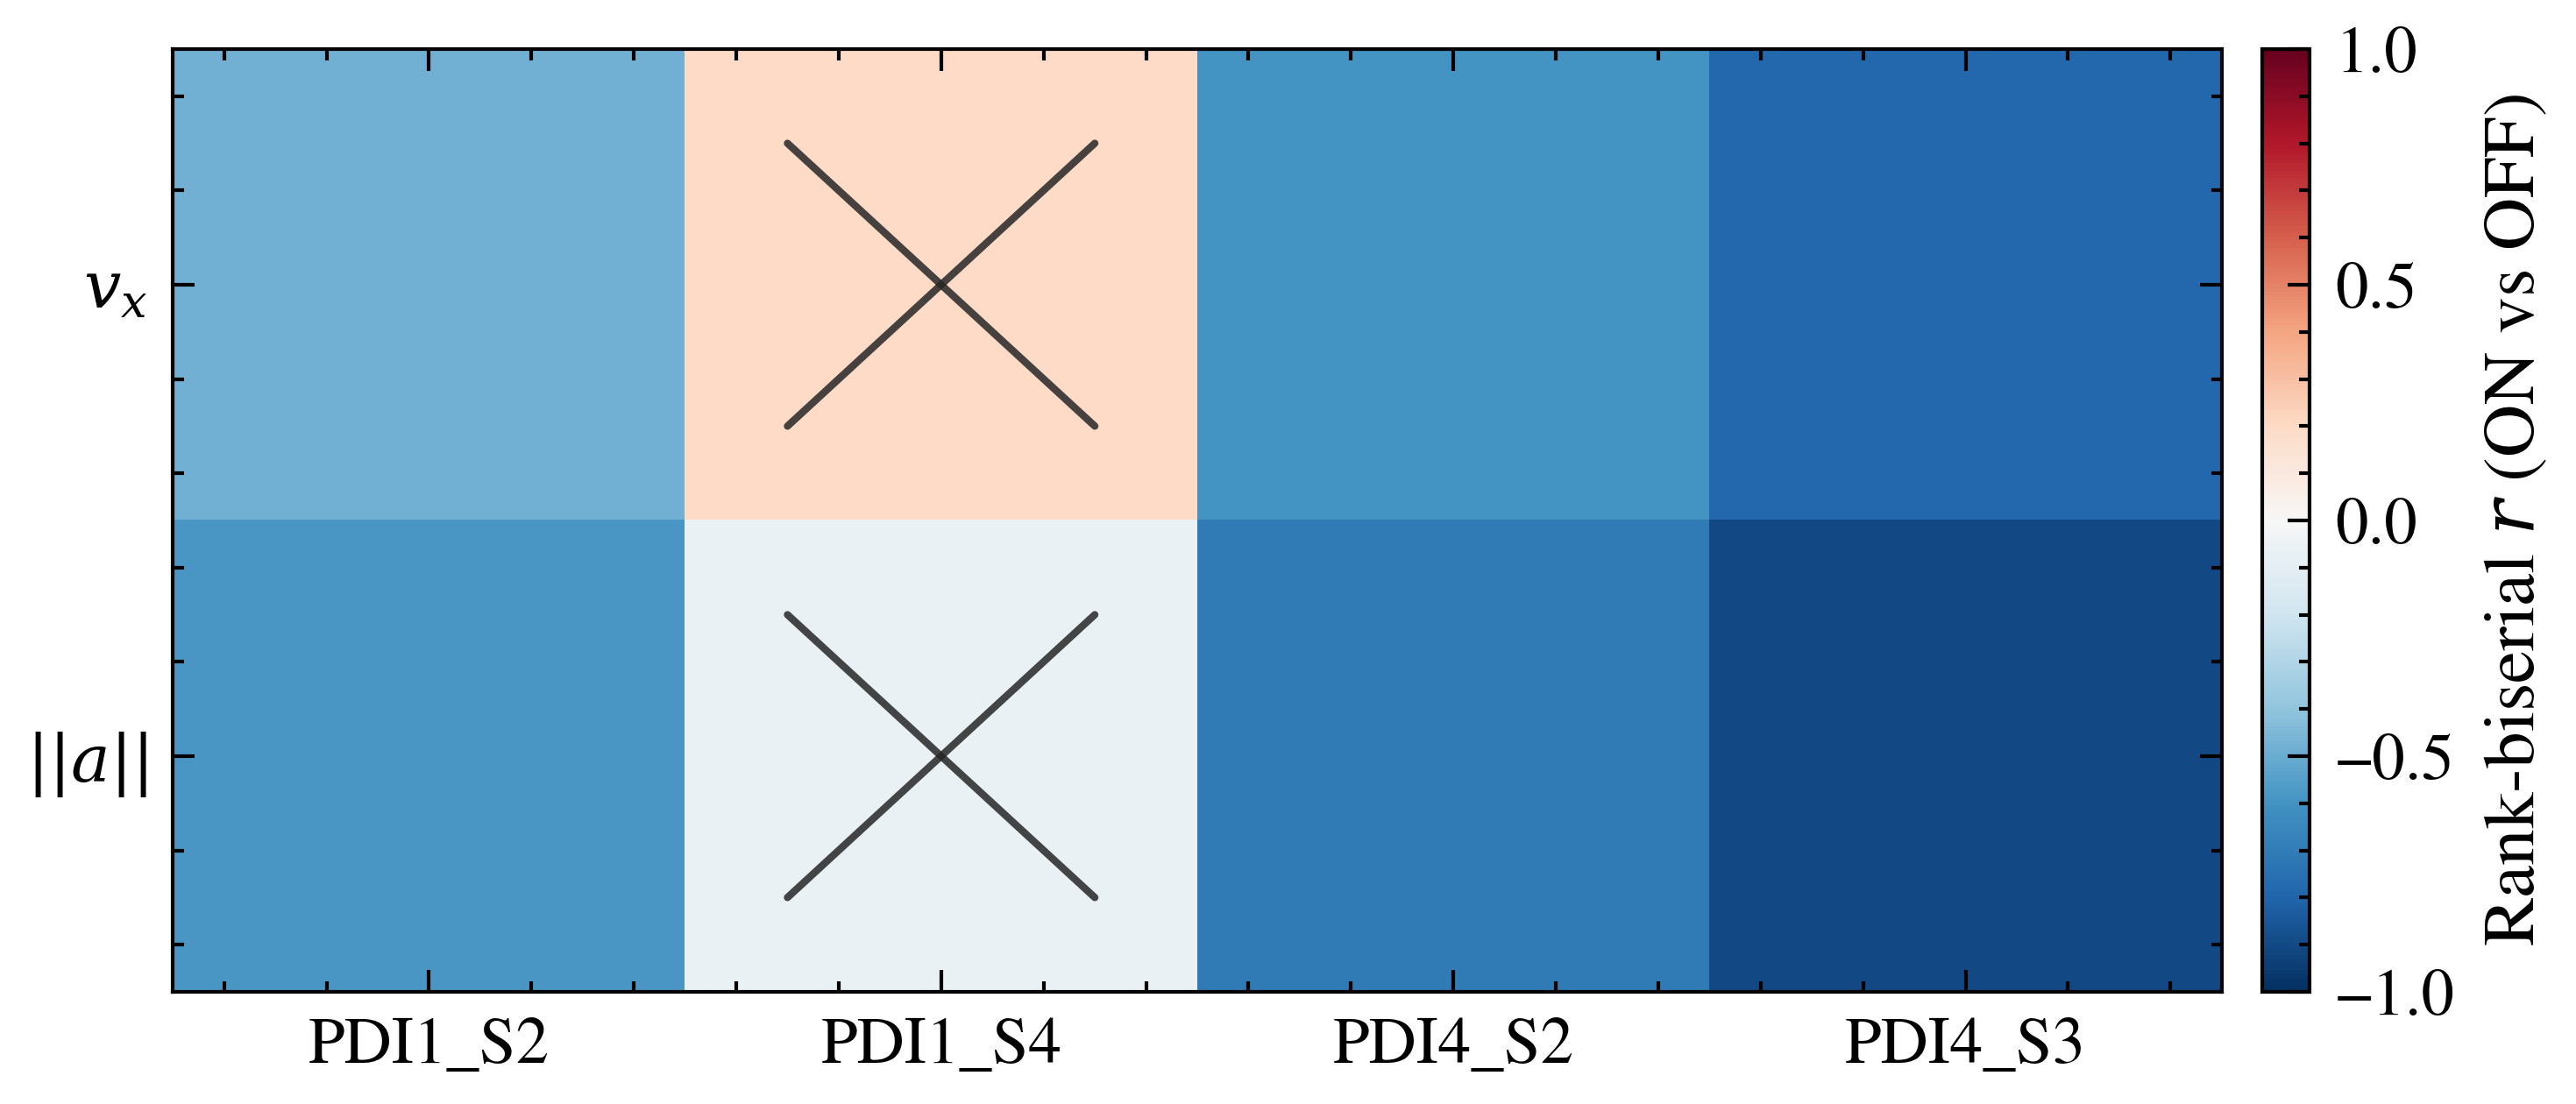

Saved -> fig_006b_beh_dbs_separability.png

Per-trial RMS Mann-Whitney U per session x kinematic channel:
session                        channel  n_on  n_off    U    p_raw     q_bh      r
PDI1_S2             tracing_velocity_x    72     72 1356 7.95e-07 7.95e-07 -0.477
PDI1_S2 tracing_acceleration_magnitude    72     72 1076 1.40e-09 2.80e-09 -0.585
PDI1_S4             tracing_velocity_x    58     58 2014 6.72e-02 1.34e-01 +0.197
PDI1_S4 tracing_acceleration_magnitude    58     58 1565 5.20e-01 5.20e-01 -0.070
PDI4_S2             tracing_velocity_x    59     60  718 2.29e-08 2.29e-08 -0.594
PDI4_S2 tracing_acceleration_magnitude    59     60  516 2.70e-11 5.39e-11 -0.708
PDI4_S3             tracing_velocity_x    72     48  369 3.41e-13 3.41e-13 -0.786
PDI4_S3 tracing_acceleration_magnitude    72     48  173 8.27e-17 1.65e-16 -0.900


In [7]:
# Behavioral DBS separability — tracing_velocity_x & tracing_acceleration_magnitude.
# Per-trial RMS, Mann-Whitney U (DBS-ON vs OFF), same encoding as the neural heatmap:
# colour is the signed rank-biserial r, cells failing BH-FDR (q >= 0.05) crossed out.

BEH_VARS = ["tracing_velocity_x", "tracing_acceleration_magnitude"]
BEH_LABELS = ["$v_x$", "$||a||$"]

beh_r = np.full((len(BEH_VARS), len(session_specs)), np.nan)   # (vars x sessions)
beh_q = np.full((len(BEH_VARS), len(session_specs)), np.nan)
beh_records = []

for si, s in enumerate(session_specs):
    fw = s.psid_variant.split("_")[0]
    base = results_root / fw / s.psid_variant / "split"
    rms_by_var = {v: {"off": [], "on": []} for v in BEH_VARS}
    for split_name in ("train", "val", "test"):
        fp = base / f"{split_name}.parquet"
        if not fp.exists():
            continue
        df = pl.read_parquet(fp, columns=["stim"] + BEH_VARS)
        for row in df.iter_rows(named=True):
            cond = "off" if row["stim"] in ("off", "0") else "on"
            for v in BEH_VARS:
                sig = np.array(row[v], dtype=float)
                sig = sig[np.isfinite(sig)]
                if len(sig) < 10:
                    continue
                rms_by_var[v][cond].append(np.sqrt(np.mean(sig**2)))
    raw_p = np.full(len(BEH_VARS), np.nan)
    r_bis = np.full(len(BEH_VARS), np.nan)
    u_stat = np.full(len(BEH_VARS), np.nan)
    n_pair = []
    for bi, v in enumerate(BEH_VARS):
        off_vals, on_vals = rms_by_var[v]["off"], rms_by_var[v]["on"]
        n_pair.append((len(on_vals), len(off_vals)))
        if len(off_vals) < 2 or len(on_vals) < 2:
            continue
        try:
            # ON vs OFF, so r > 0 means larger RMS under DBS-ON.
            u_stat[bi], raw_p[bi] = mannwhitneyu(
                on_vals, off_vals, alternative="two-sided"
            )
        except ValueError:
            continue
        r_bis[bi] = 2.0 * u_stat[bi] / (len(on_vals) * len(off_vals)) - 1.0
    # Benjamini-Hochberg FDR across the behavioral variables, within this session.
    valid = np.isfinite(raw_p)
    if valid.any():
        adj_v = multipletests(raw_p[valid], alpha=ALPHA_SIG, method="fdr_bh")[1]
        beh_q[np.flatnonzero(valid), si] = adj_v
    beh_r[:, si] = r_bis
    for bi, v in enumerate(BEH_VARS):
        beh_records.append(
            {
                "session": s.label,
                "channel": v,
                "n_on": n_pair[bi][0],
                "n_off": n_pair[bi][1],
                "U": u_stat[bi],
                "p_raw": raw_p[bi],
                "q_bh": beh_q[bi, si],
                "r": r_bis[bi],
            }
        )

sess_labels = [s.label for s in session_specs]
fig, ax = plt.subplots(figsize=(5.0, 2.2), layout="constrained")
finite = np.isfinite(beh_r)
ax.imshow(
    np.where(finite, beh_r, 0.0),
    aspect="auto",
    cmap="RdBu_r",
    vmin=-1.0,
    vmax=1.0,
    alpha=np.where(finite, 1.0, 0.0),
    interpolation="nearest",
)
_cross_nonsig(ax, beh_q, finite)
ax.set_xticks(range(len(session_specs)))
ax.set_xticklabels(sess_labels)
ax.set_yticks(range(len(BEH_VARS)))
ax.set_yticklabels(BEH_LABELS)

sm_beh = cm.ScalarMappable(cmap="RdBu_r", norm=plt.Normalize(vmin=-1.0, vmax=1.0))
fig.colorbar(
    sm_beh, ax=ax, label="Rank-biserial $r$ (ON vs OFF)", fraction=0.06, pad=0.02
)
fig.savefig(str(OUT / "fig_006b_beh_dbs_separability.png"))
plt.show()
print("Saved -> fig_006b_beh_dbs_separability.png")

print("\nPer-trial RMS Mann-Whitney U per session x kinematic channel:")
print(
    pd.DataFrame(beh_records).to_string(
        index=False,
        formatters={
            "U": "{:.0f}".format,
            "p_raw": "{:.2e}".format,
            "q_bh": "{:.2e}".format,
            "r": "{:+.3f}".format,
        },
    )
)


## PSID hyperparameter selection (nx, n1)

nx chosen by peak Z Pearson's r on the validation set,
sweeping nx ∈ {4, 8, 16, 32, 64} with n1 fixed. All sessions converge to nx = 64.

n1 chosen by peak Z Pearson's r on the validation set, sweeping n1 ∈ {1, 2, 4, 8, 16, 32}
with nx = 64. Evaluated separately for z-as-behavior (orange) and z-as-neural (blue).
Dotted vertical lines mark the chosen value per experiment.

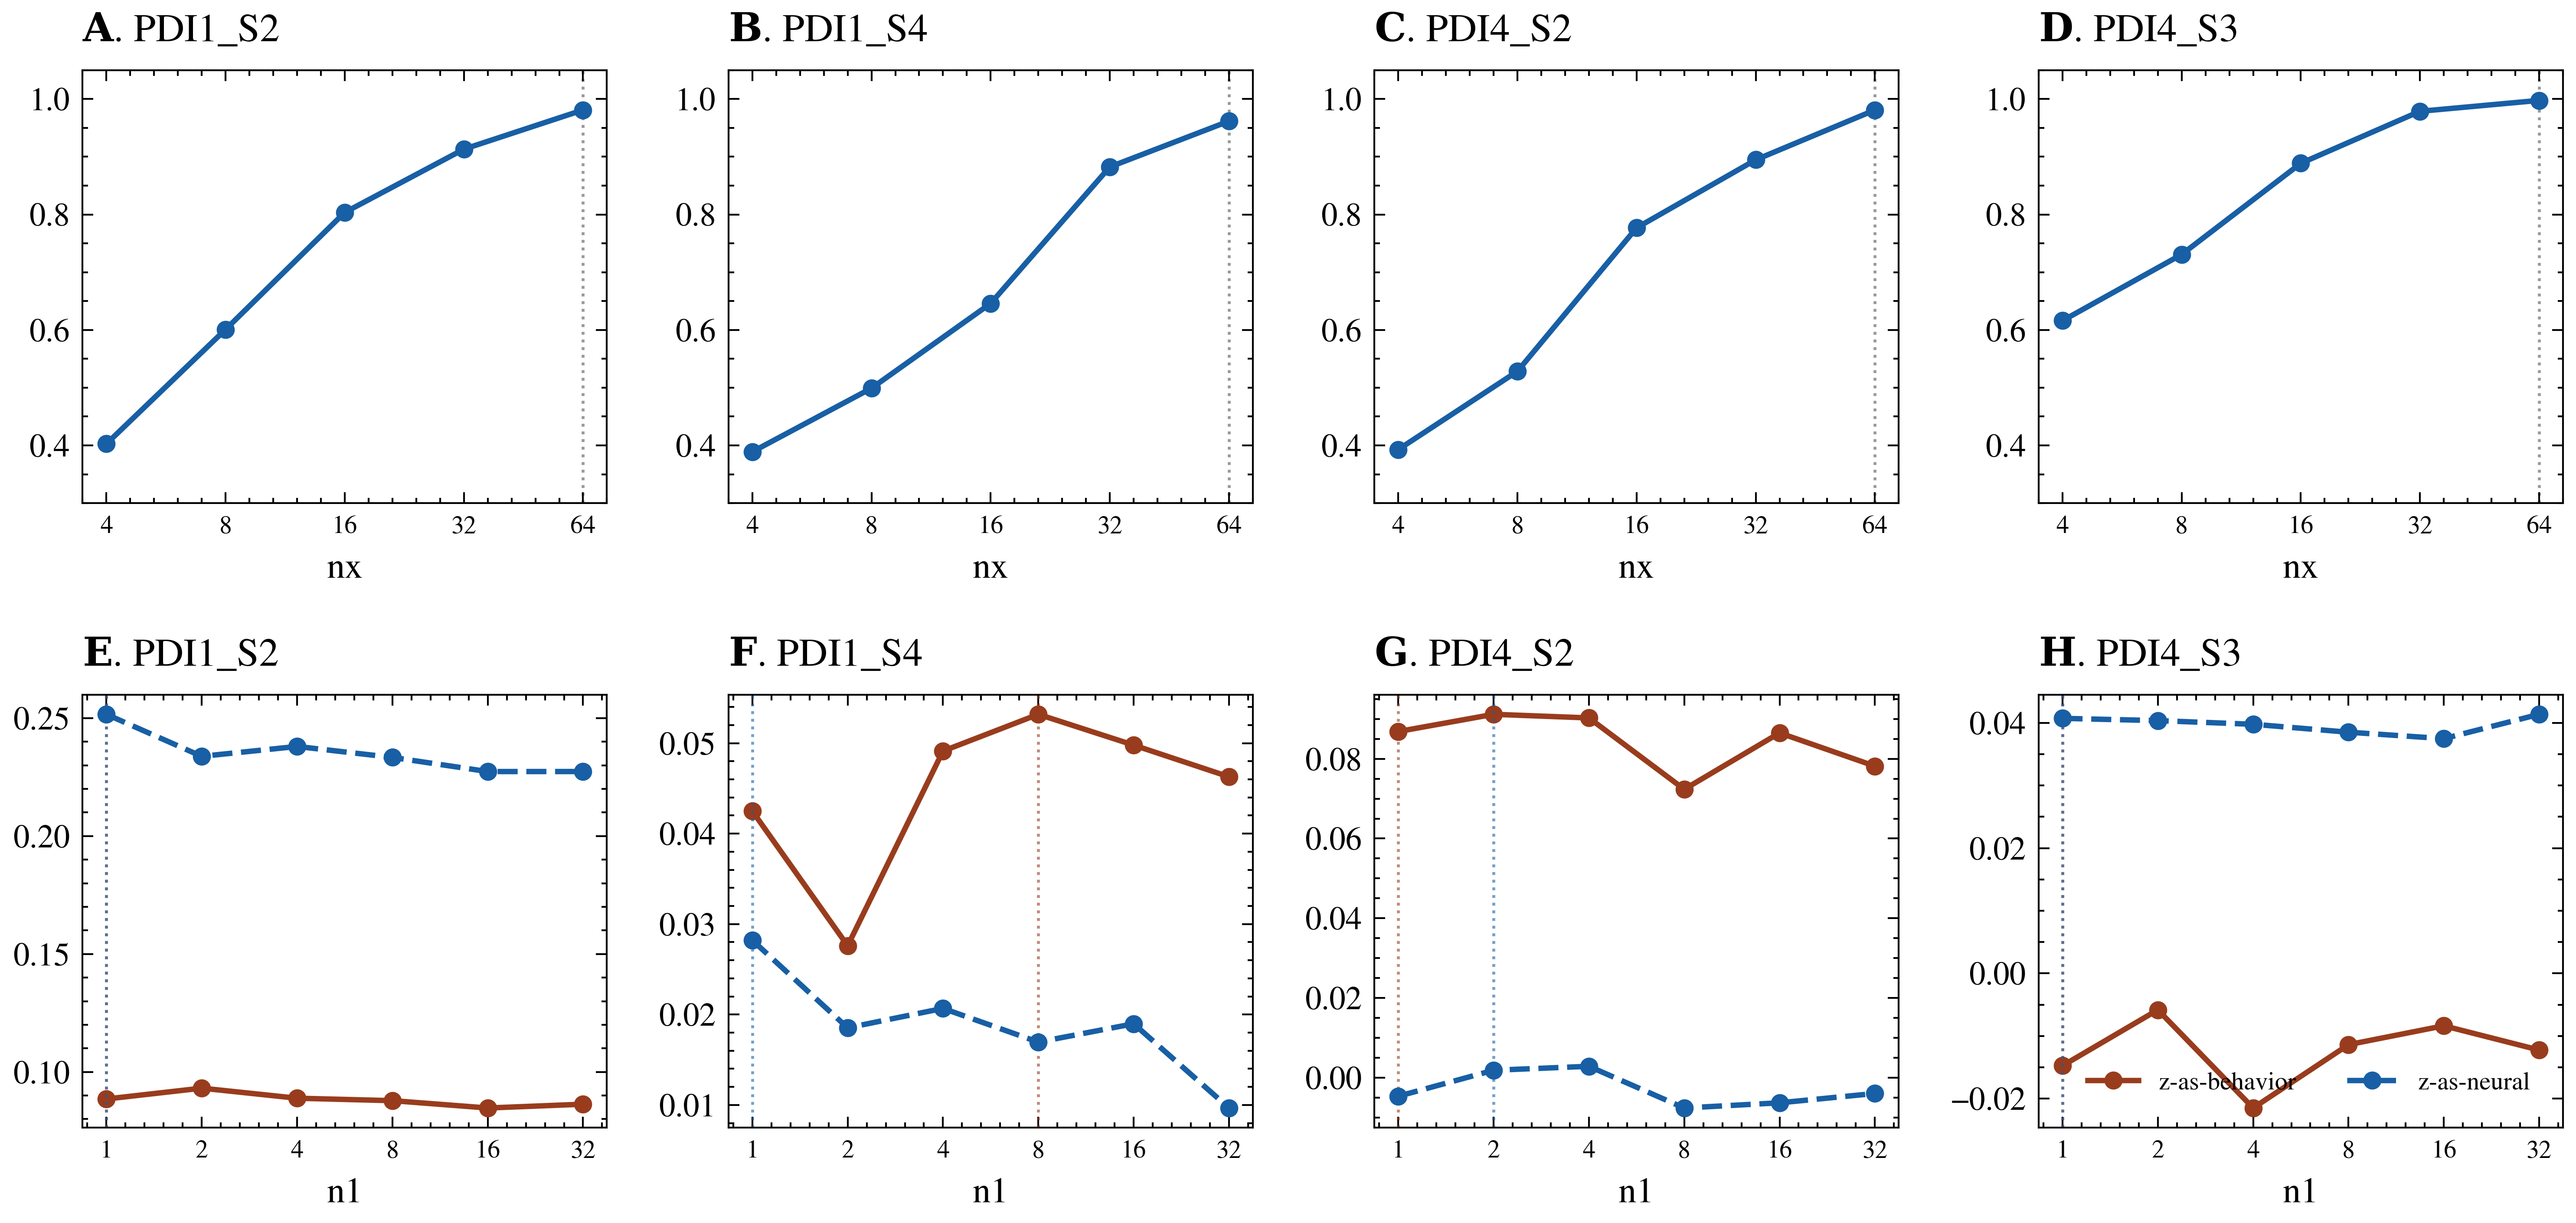

PSID hyperparameter selection. Top row (A-D): Z Pearson's r vs nx on the validation set — all 4 sessions select nx=64 (dotted line). Bottom row (E-H): Z Pearson's r vs n1 on the validation set — orange=z-as-behavior, blue=z-as-neural; dotted verticals mark the chosen n1 per experiment. n1_grid=[1,2,4,8,16,32]; nx_grid=[4,8,16,32,64].


In [8]:
diag_root = results_root / "psid_diagnostic"

diag_data = {}
for sess in SESSIONS:
    diag_data[sess] = {}
    for exp in [EXP_Z_AS_BEHAVIOR, EXP_Z_AS_NEURAL]:
        dirs = sorted((diag_root / f"{sess}_{exp}").glob("*/"))
        df = pl.read_parquet(dirs[-1] / "diagnostic.parquet")
        diag_data[sess][exp] = df.row(0, named=True)

fig, axes = plt.subplots(2, 4, figsize=(10.0, 4.8), constrained_layout=True)

for col, sess in enumerate(SESSIONS):
    # Row 0: nx selection — Z Pearson's r vs nx (same for both experiments)
    ax = axes[0, col]
    row = diag_data[sess][EXP_Z_AS_BEHAVIOR]
    nx_grid = list(row["nx_grid"])
    nx_val = list(row["nx_val_mean"])
    chosen_nx = row["chosen_nx"]
    x_nx = list(range(len(nx_grid)))
    ax.plot(x_nx, nx_val, color=COLOR_PSID, marker="o", ms=4, lw=1.5)
    ax.axvline(nx_grid.index(chosen_nx), color="#999", lw=0.8, ls=":", zorder=0)
    ax.set_xticks(x_nx)
    ax.set_xticklabels([str(v) for v in nx_grid], fontsize=7)
    ax.set_ylim(0.3, 1.05)
    ax.set_xlabel("nx")
    panel_label(ax, chr(65 + col), sess)

    # Row 1: n1 selection — Z Pearson's r vs n1, separate per experiment
    ax = axes[1, col]
    n1_grid = None
    for exp, color in [(EXP_Z_AS_BEHAVIOR, COLOR_DPAD), (EXP_Z_AS_NEURAL, COLOR_PSID)]:
        row = diag_data[sess][exp]
        n1_grid = list(row["n1_grid"])
        n1_z = list(row["n1_z_mean"])
        chosen_n1 = row["chosen_n1"]
        x_n1 = list(range(len(n1_grid)))
        lbl = exp if col == len(SESSIONS) - 1 else None
        ax.plot(x_n1, n1_z, color=color, marker="o", ms=4, lw=1.5, label=lbl)
        ax.axvline(n1_grid.index(chosen_n1), color=color, lw=0.8, ls=":", alpha=0.6)
    ax.set_xticks(list(range(len(n1_grid))))
    ax.set_xticklabels([str(v) for v in n1_grid], fontsize=7)
    ax.set_xlabel("n1")
    panel_label(ax, chr(69 + col), sess)

axes[1, -1].legend(loc="lower right", ncol=2, fontsize=7)
fig.savefig(str(OUT / "fig_007_nx_n1_selection.png"))
plt.show()
print(
    "PSID hyperparameter selection. Top row (A-D): Z Pearson's r vs nx on the "
    "validation set — all 4 sessions select nx=64 (dotted line). "
    "Bottom row (E-H): Z Pearson's r vs n1 on the validation set — orange=z-as-behavior, "
    "blue=z-as-neural; dotted verticals mark the chosen n1 per experiment. "
    "n1_grid=[1,2,4,8,16,32]; nx_grid=[4,8,16,32,64]."
)

## DPAD training curves (4-stage convergence)

DPAD trains in 4 sequential internal stages: model1 -> model1_Cy -> model2 -> model2_Cz
(see CLAUDE.md model hierarchy). Each panel concatenates all 4 stages along the x-axis;
dotted verticals mark stage boundaries. Solid = train NRMSE, dashed = validation NRMSE.
Top row = z-as-neural, bottom row = z-as-behavior. Canonical
dbs_both run per session (same run used elsewhere in sec2/sec5).

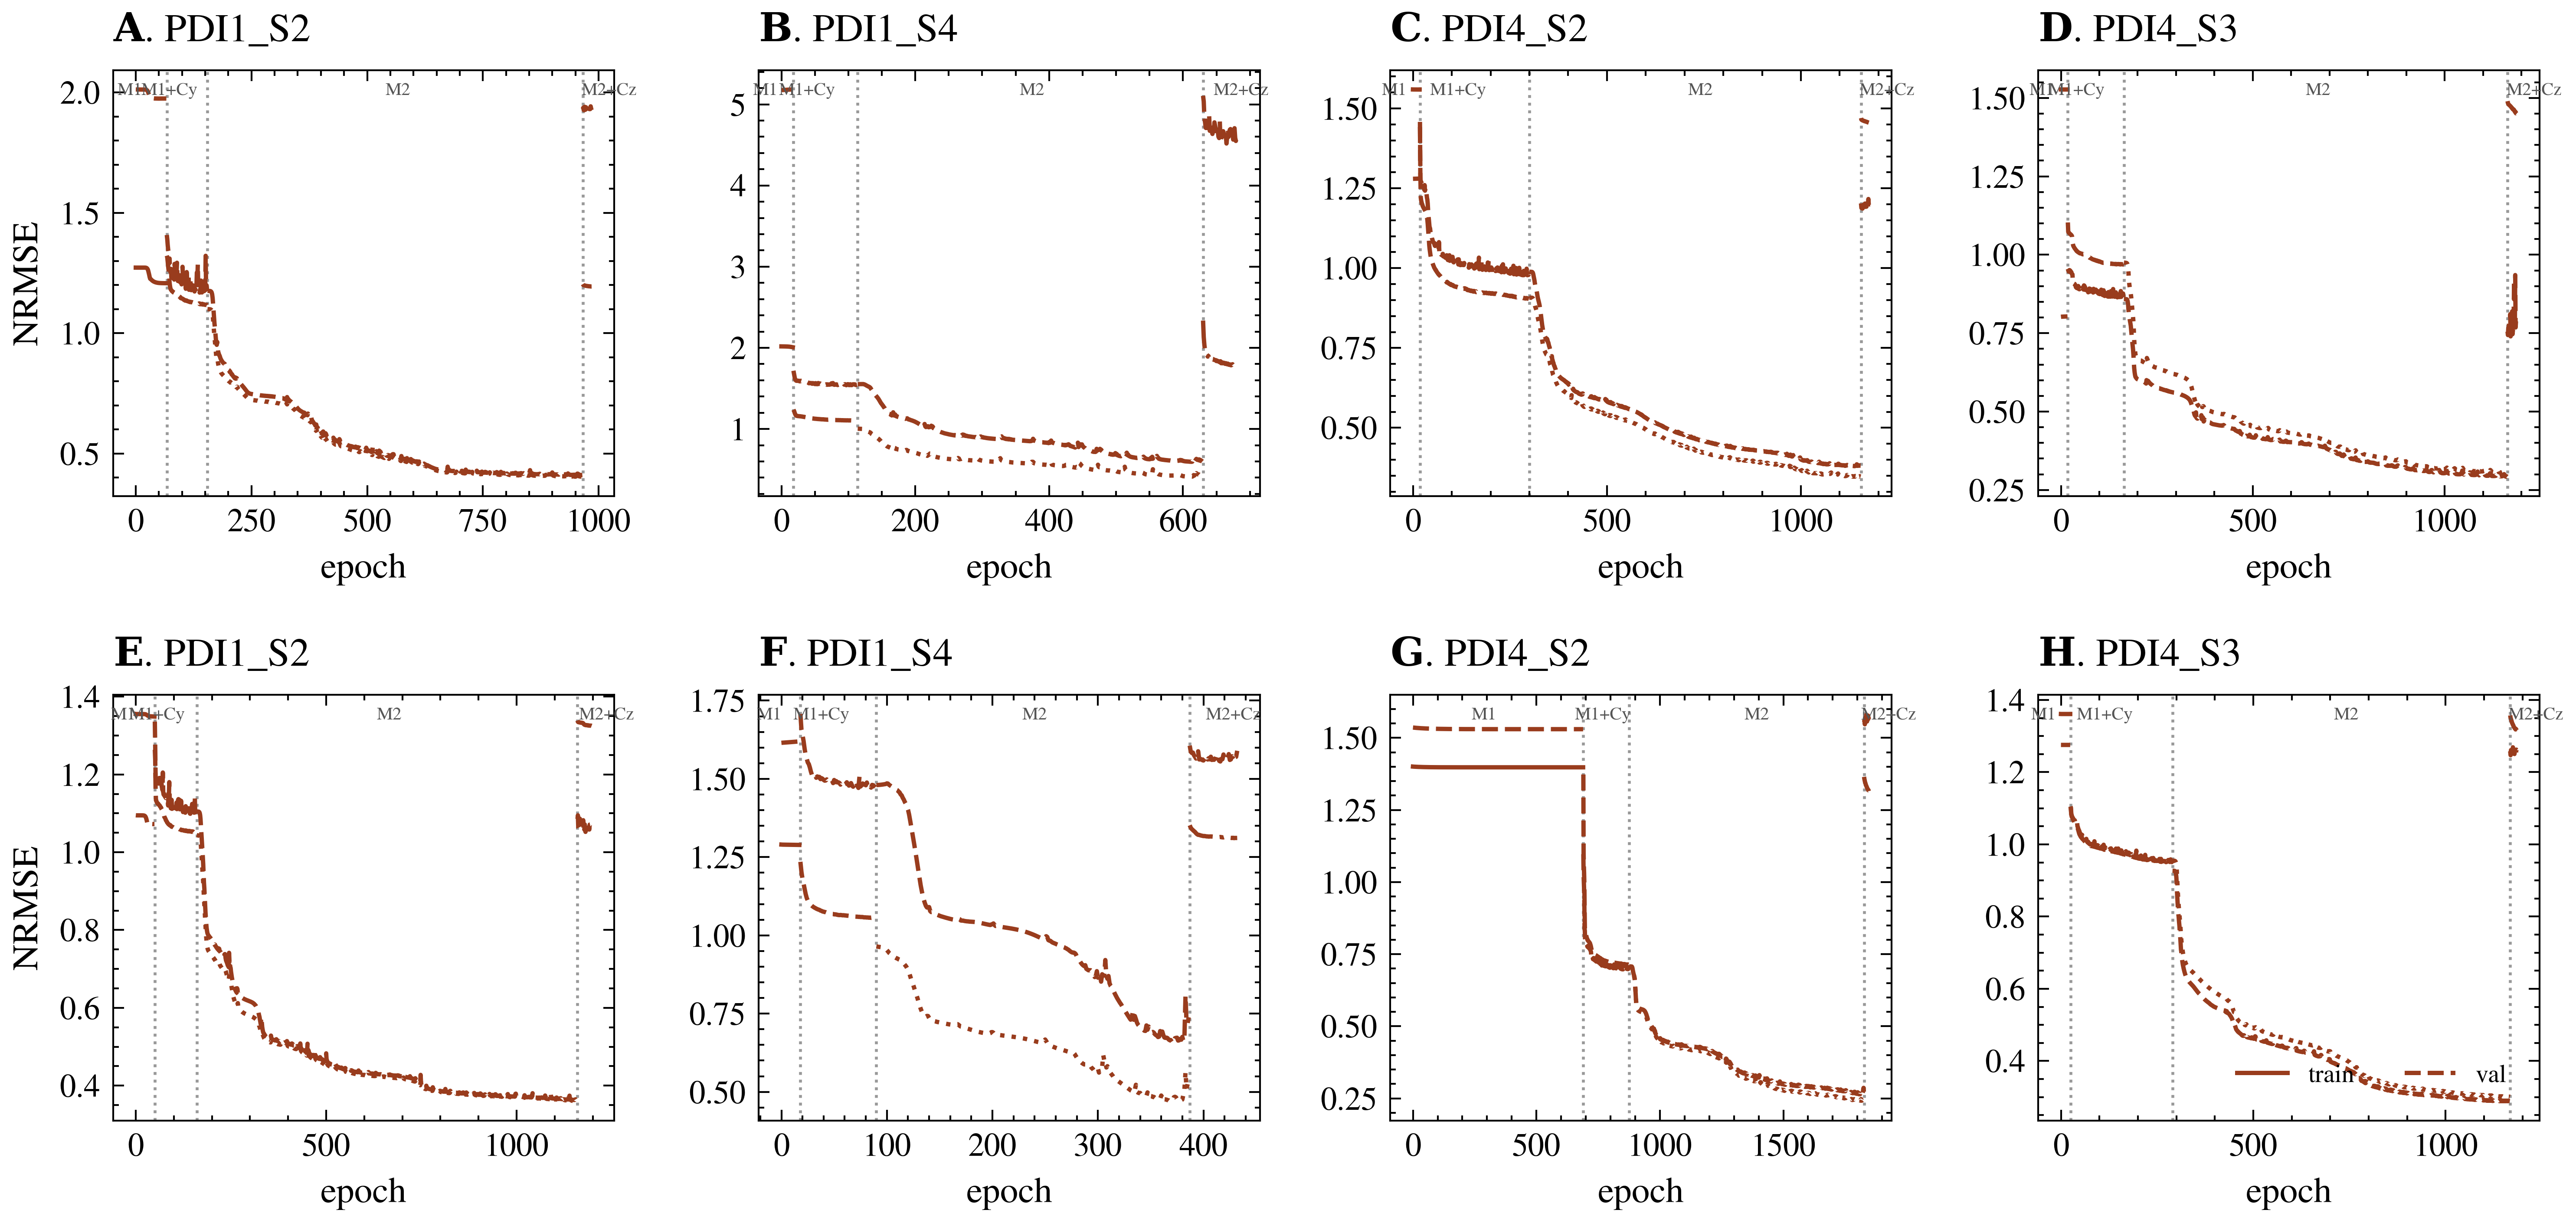

DPAD 4-stage training convergence (M1=model1, M1+Cy=model1_Cy, M2=model2, M2+Cz=model2_Cz). Top row (A-D): z-as-neural; bottom row (E-H): z-as-behavior. Solid = train NRMSE, dashed = validation NRMSE; dotted verticals mark stage boundaries. Canonical dbs_both run per session.


In [9]:
DPAD_STAGES = ["model1", "model1_Cy", "model2", "model2_Cz"]
DPAD_STAGE_LABELS = ["M1", "M1+Cy", "M2", "M2+Cz"]

dpad_history = {}
for sess in SESSIONS:
    dpad_history[sess] = {}
    for exp in [EXP_Z_AS_NEURAL, EXP_Z_AS_BEHAVIOR]:
        vdir = get_latest_variant_dir(
            results_root, "dpad", exp, sess, condition="dbs_both"
        )
        base_dir = vdir.parent / vdir.name.removesuffix("_dbs_both")
        with open(base_dir / "training_history.json") as f:
            dpad_history[sess][exp] = json.load(f)

fig, axes = plt.subplots(2, 4, figsize=(10.0, 4.8), constrained_layout=True)

for col, sess in enumerate(SESSIONS):
    for row_idx, exp in enumerate([EXP_Z_AS_NEURAL, EXP_Z_AS_BEHAVIOR]):
        ax = axes[row_idx, col]
        hist = dpad_history[sess][exp]

        stage_ranges = []
        offset = 0
        for stage in DPAD_STAGES:
            n_epoch = len(hist[stage]["epochs"])
            stage_ranges.append((offset, offset + n_epoch))
            offset += n_epoch
        total_epochs = offset

        for si, stage in enumerate(DPAD_STAGES):
            x_start, x_end = stage_ranges[si]
            x = list(range(x_start, x_end))
            ax.plot(x, hist[stage]["rmse"], color=COLOR_DPAD, lw=1.2)
            ax.plot(x, hist[stage]["val_rmse"], color=COLOR_DPAD, lw=1.2, ls="--")
            if si < len(DPAD_STAGES) - 1:
                ax.axvline(x_end, color="#999", lw=0.8, ls=":", zorder=0)
            x_frac = (x_start + x_end) / 2 / total_epochs
            ax.text(x_frac, 0.97, DPAD_STAGE_LABELS[si],
                    transform=ax.transAxes, ha="center", va="top",
                    fontsize=5, color="#555")

        ax.set_xlabel("epoch")
        if col == 0:
            ax.set_ylabel("NRMSE")
        letter = chr(65 + col) if row_idx == 0 else chr(69 + col)
        panel_label(ax, letter, sess)

axes[-1, -1].plot([], [], color=COLOR_DPAD, lw=1.2, label="train")
axes[-1, -1].plot([], [], color=COLOR_DPAD, lw=1.2, ls="--", label="val")
axes[-1, -1].legend(loc="lower right", ncol=2, fontsize=7)
fig.savefig(str(OUT / "fig_008_dpad_training_curves.png"))
plt.show()
print(
    "DPAD 4-stage training convergence (M1=model1, M1+Cy=model1_Cy, M2=model2, M2+Cz=model2_Cz). "
    "Top row (A-D): z-as-neural; bottom row (E-H): z-as-behavior. Solid = train NRMSE, "
    "dashed = validation NRMSE; dotted verticals mark stage boundaries. "
    "Canonical dbs_both run per session."
)

## Section 3.0 — Bullet points (copy into thesis)

- **Trial counts.** After removing fragmented blocks and plateau trials (cursor stationary > 2 s), usable trial counts were 144 (PDI1\_S2), 116 (PDI1\_S4), 119 (PDI4\_S2), and 120 (PDI4\_S3). Trials were split chronologically into train / val / test sets; DBS-ON and DBS-OFF conditions were balanced in train and test splits for all sessions. Note: PDI4\_S3 validation set contains only DBS-ON trials (0 DBS-OFF) due to the chronological split landing on a pure-ON block.

- **PSD separation.** PDI4\_S2 and PDI4\_S3 show consistent DBS-ON vs DBS-OFF power differences across gamma-band frequencies (30–80 Hz), with Mann-Whitney U tests reaching $p < 0.05$ in multiple bands for both ECoG and Laplacian channels. PDI1\_S2 and PDI1\_S4 show little to no spectral separation between conditions across all bands and channel types.

- **Spectral separability ceiling.** The absence of DBS-modulated signal in PDI1 sessions imposes a hard ceiling on any decoding approach: models cannot recover state information that is not encoded in the neural signal. Chance-level decoding performance on PDI1 throughout all subsequent RQs should be interpreted as a data property rather than a model failure.

- **Behavioral kinematics.** Mean velocity and acceleration traces are visually similar between DBS-ON and DBS-OFF conditions in all four sessions (overlapping SEM bands), consistent with the cursor-tracing task being self-paced and not directly modulated by stimulation at the kinematic level.

## Verification prints (traceability for 04_00)


In [10]:
from modules.utils import normalize_stim
# --- Printed source for 04_00 neural DBS significance (backs band ranges + per-session r/q) ---
# Pooled test: one Mann-Whitney U per session x band on channel-pooled band power.
def _sig_bands(r_row, q_row):
    out = []
    for (bn, lo, hi), r, q in zip(BAND_ORDER, r_row, q_row):
        if not np.isfinite(q) or q >= ALPHA_SIG:
            continue
        out.append(f"{lo}-{hi}Hz(r={r:+.3f}, q={q:.1e})")
    return out


print("DBS band separability, BH-FDR q < 0.05 (ECoG, 4 channels pooled):")
for si, lab in enumerate(sess_labels):
    b = _sig_bands(rmat_ecog[si], qmat_ecog[si])
    print(f"  {lab:10s} {', '.join(b) if b else 'none q<0.05'}")
print(
    "\nDBS band separability, BH-FDR q < 0.05 "
    "(Laplacian LFP 9-16, pooled):"
)
for si, lab in enumerate(sess_labels):
    b = _sig_bands(rmat_lap[si], qmat_lap[si])
    print(f"  {lab:10s} {', '.join(b) if b else 'none q<0.05'}")


DBS band separability, BH-FDR q < 0.05 (ECoG, 4 channels pooled):
  PDI1_S2    37-42Hz(r=-0.361, q=1.6e-03), 42-47Hz(r=-0.375, q=1.6e-03)
  PDI1_S4    none q<0.05
  PDI4_S2    18-23Hz(r=-0.398, q=7.9e-04), 23-28Hz(r=-0.751, q=1.4e-11), 28-32Hz(r=-0.798, q=1.0e-12), 32-37Hz(r=-0.622, q=2.8e-08), 37-42Hz(r=-0.310, q=1.2e-02)
  PDI4_S3    4-8Hz(r=+0.392, q=5.5e-04), 13-18Hz(r=-0.401, q=4.4e-04), 18-23Hz(r=-0.800, q=5.5e-13), 23-28Hz(r=-0.976, q=2.9e-18), 28-32Hz(r=-0.964, q=4.1e-18), 32-37Hz(r=-0.898, q=5.4e-16), 37-42Hz(r=-0.675, q=1.4e-09), 42-47Hz(r=-0.337, q=2.6e-03), 68-73Hz(r=+0.492, q=1.5e-05), 73-78Hz(r=+0.388, q=5.7e-04), 83-88Hz(r=-0.365, q=1.2e-03), 88-93Hz(r=-0.444, q=9.8e-05)

DBS band separability, BH-FDR q < 0.05 (Laplacian LFP 9-16, pooled):
  PDI1_S2    4-8Hz(r=-0.349, q=5.5e-04), 8-12Hz(r=-0.391, q=2.2e-04), 13-18Hz(r=-0.355, q=5.5e-04), 18-23Hz(r=-0.392, q=2.2e-04), 23-28Hz(r=-0.299, q=3.0e-03), 28-32Hz(r=-0.226, q=2.3e-02), 32-37Hz(r=-0.206, q=3.5e-02), 37-42Hz(r=-0.29

In [11]:
# --- Printed source for 04_00 behavior significance + split-seconds table ---
print("Behavioral DBS separability, BH-FDR q and signed r (Mann-Whitney U per session):")
print(f"  {'session':10s} {'v_x q':>10s} {'v_x r':>8s} {'||a|| q':>10s} {'||a|| r':>8s}")
for si, lab in enumerate(sess_labels):
    cells = []
    for bi in range(len(BEH_VARS)):
        q, r = beh_q[bi, si], beh_r[bi, si]
        cells.append(f"{q:.1e}" if np.isfinite(q) else "n/a")
        cells.append(f"{r:+.3f}" if np.isfinite(r) else "n/a")
    print(f"  {lab:10s} {cells[0]:>10s} {cells[1]:>8s} {cells[2]:>10s} {cells[3]:>8s}")

print("\nUsable data per split (seconds; OFF/ON trial counts), 1 trial = 9 s:")
print(f"  {'session':10s} {'split':6s} {'sec':>7s} {'off':>4s} {'on':>4s}")
for s in session_specs:
    fw = s.psid_variant.split("_")[0]
    base = results_root / fw / s.psid_variant / "split"
    tot = 0
    for split_name in ("train", "val", "test"):
        fp = base / f"{split_name}.parquet"
        if not fp.exists():
            continue
        df = pl.read_parquet(fp, columns=["stim"])
        stims = [normalize_stim(v) for v in df["stim"].to_list()]
        n_off = sum(1 for v in stims if v == "off")
        n_on = sum(1 for v in stims if v == "on")
        tot += 9 * len(df)
        print(f"  {s.label:10s} {split_name:6s} {9*len(df):7d} {n_off:4d} {n_on:4d}")
    print(f"  {s.label:10s} {'TOTAL':6s} {tot:7d}")


Behavioral DBS separability, BH-FDR q and signed r (Mann-Whitney U per session):
  session         v_x q    v_x r    ||a|| q  ||a|| r
  PDI1_S2       8.0e-07   -0.477    2.8e-09   -0.585
  PDI1_S4       1.3e-01   +0.197    5.2e-01   -0.070
  PDI4_S2       2.3e-08   -0.594    5.4e-11   -0.708
  PDI4_S3       3.4e-13   -0.786    1.7e-16   -0.900

Usable data per split (seconds; OFF/ON trial counts), 1 trial = 9 s:
  session    split      sec  off   on
  PDI1_S2    train      648   36   36
  PDI1_S2    val        216   12   12
  PDI1_S2    test       432   24   24
  PDI1_S2    TOTAL     1296
  PDI1_S4    train      432   24   24
  PDI1_S4    val        207   12   11
  PDI1_S4    test       405   22   23
  PDI1_S4    TOTAL     1044
  PDI4_S2    train      423   24   23
  PDI4_S2    val        216   12   12
  PDI4_S2    test       432   24   24
  PDI4_S2    TOTAL     1071
  PDI4_S3    train      432   24   24
  PDI4_S3    val        216    0   24
  PDI4_S3    test       432   24   24
  PDI4